In [57]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data[:, [0, 1]], data.target
feature_names = data.feature_names
target_names = data.target_names

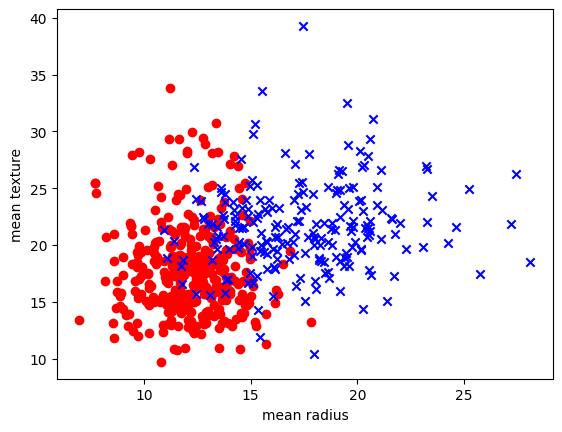

In [58]:
import matplotlib.pyplot as plt
import numpy as np

X_with_y_1 = np.array(X[y == 1])
X_with_y_0 = np.array(X[y == 0])

plt.scatter(x=X_with_y_1[:, 0], y=X_with_y_1[:, 1], marker='o', color='r')
plt.scatter(x=X_with_y_0[:, 0], y=X_with_y_0[:, 1], marker='x', color='blue')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2, stratify=y)
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)[:, [0, 1]]
X_test_std = sc.transform(X_test)[:, [0, 1]]
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

X_combined_std

array([[-0.76963893,  0.25751532],
       [-0.54370781,  0.0670848 ],
       [-0.53255072, -0.31377623],
       ...,
       [-0.87005276, -0.49956211],
       [-0.48792235, -0.52742999],
       [ 0.09782499,  0.01599369]], shape=(569, 2))

In [61]:
from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'o', 'x', '^', 'v')
    colors = ('black', 'red', 'blue', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='white')
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0], X_test[:, 1], c='none',
                    edgecolor='black', marker='o',
                    s=100, label='Test set')

In [85]:
from sklearn.linear_model import LogisticRegression

models = []
lr = LogisticRegression()
lr.fit(X_train_std, y_train)
models.append(lr)

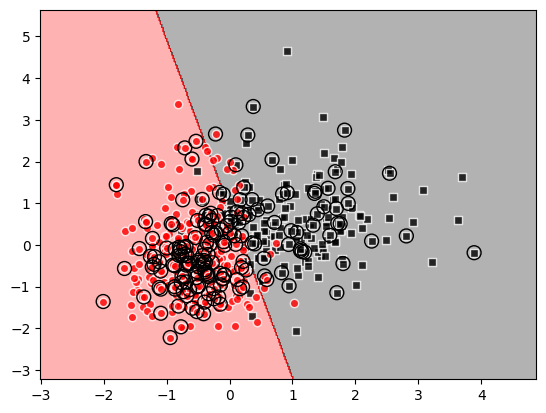

In [86]:
plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=lr,
                      test_idx=range((X_train_std.shape[0] + 1), X_combined_std.shape[0]))


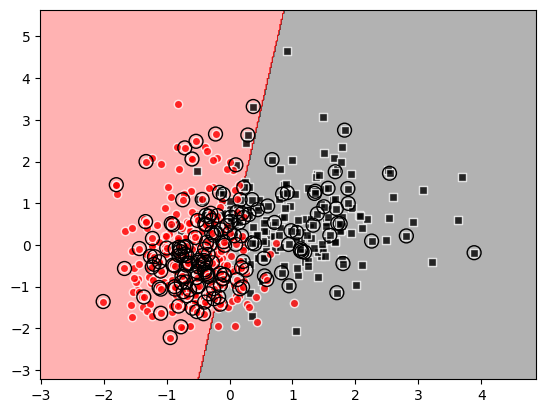

In [87]:
from sklearn.linear_model import Perceptron

ppn = Perceptron()
ppn.fit(X_train_std, y_train)
models.append(ppn)
plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=ppn,
                      test_idx=range((X_train_std.shape[0] + 1), X_combined_std.shape[0]))

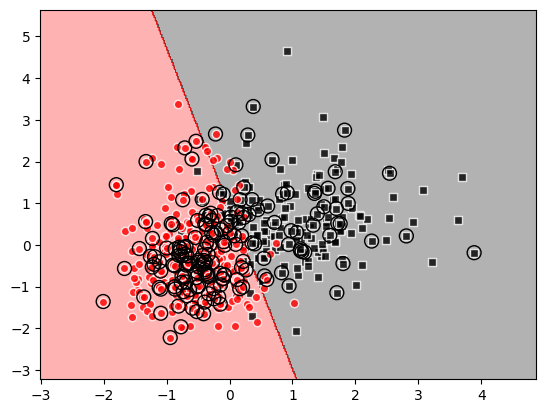

In [88]:
from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(X_train_std, y_train)
models.append(svc)
plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=svc,
                      test_idx=range((X_train_std.shape[0] + 1), X_combined_std.shape[0]))

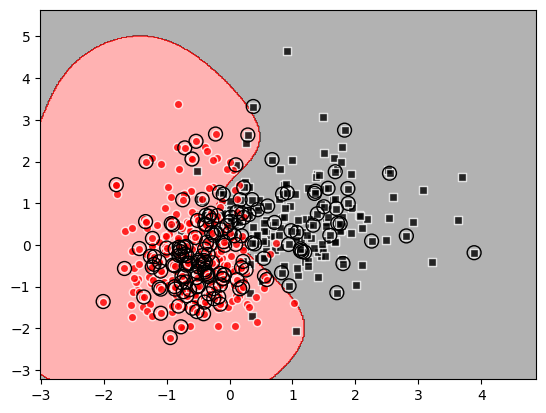

In [89]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train_std, y_train)
models.append(svc)
plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=svc,
                      test_idx=range((X_train_std.shape[0] + 1), X_combined_std.shape[0]))

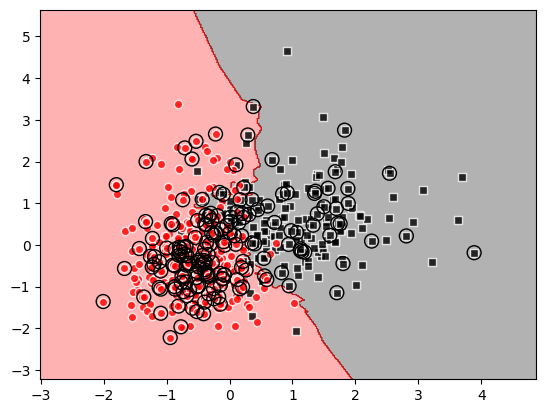

In [90]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_std, y_train)
models.append(knn)
plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=knn,
                      test_idx=range((X_train_std.shape[0] + 1), X_combined_std.shape[0]))

In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metrics_data = []
for model in models:
    y_pred = model.predict(X_test_std)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    metrics_data.append({
        'Model': model,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
    })
models_df = pd.DataFrame(metrics_data)
models_df



,Model,Accuracy,Precision,Recall,F1-score
0,LogisticRegression(),0.871345,0.863248,0.943925,0.901786
1,Perceptron(),0.824561,0.859813,0.859813,0.859813
2,SVC(kernel='linear'),0.871345,0.863248,0.943925,0.901786
3,SVC(),0.888889,0.879310,0.953271,0.914798
4,KNeighborsClassifier(),0.871345,0.863248,0.943925,0.901786


In [114]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear', 'saga']
    },
    None, None,
    {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1]
    },

    {
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },

]
best_params_dict = {"Model": [],
                    'Best params': [],
                    'Accuracy': [], }
for model, params in zip(models, param_grid):
    if params:
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=params,
            scoring='accuracy',
            cv=5,
        )
        grid_search.fit(X_train_std, y_train)
        best_params_dict['Model'].append(grid_search.best_estimator_.__class__.__name__)
        best_params_dict['Best params'].append(grid_search.best_params_)
        best_params_dict['Accuracy'].append(grid_search.best_score_)

best_params_df = pd.DataFrame(best_params_dict)
best_params_df


,Model,Best params,Accuracy
0,LogisticRegression,"{'C': 10, 'solver': 'lbfgs'}",0.897057
1,SVC,"{'C': 0.1, 'gamma': 1}",0.909652
2,KNeighborsClassifier,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.914684
